<a href="https://colab.research.google.com/github/KSH0166/DLHW/blob/main/Lessons/Multimodality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multimodality: Build Small English Learning Tools
**Beginner Google Colab workshop • Instructor: Mary • English Education**

Today you will read, change, and run Python code that works with **text, images, audio, and video**. You will also try three small English learning apps inside this notebook.

### Learning goals
- Explain how different modes contribute to meaning.
- Store and edit a sentence, display and change an image, play audio, and create a short video.
- Modify three working learning apps and explain your design choices.

### Suggested lesson plan (about 50 minutes)
| Stage | Minutes | Activity |
|---|---:|---|
| Introduction and setup | 5 | Discuss modes; run setup |
| Text and images + App 1 | 10 | Picture vocabulary quiz |
| Audio + App 2 | 10 | Listen and type |
| Video + App 3 | 10 | Watch and choose |
| Pair design and reflection | 10 | Adapt an app; explain choices |

### How to use this notebook
1. Upload this `.ipynb` file at **https://colab.research.google.com/** using **File → Upload notebook**.
2. Connect to a runtime. A standard CPU runtime is enough.
3. Run cells from top to bottom using the ▶ button or **Shift + Enter**.
4. First run the example. Then change one value and run it again.
5. Keep quotation marks around text. Python uses indentation to group instructions.

**Teacher tip:** Students can work in pairs: one changes the code; the other predicts and explains the result. Switch roles after each app.


## 0. What is multimodality?
A **mode** is a way of making meaning, such as written language, spoken language, images, gesture, or movement. A **medium** is a channel or material that carries a message, such as a webpage or a video file. A video can combine several modes.

In this workshop, we organize practice by four media types: text, image, audio, and video. Adding more media does not automatically improve learning. Ask: **What does each element help the learner understand or do?**

**Warm-up:** Imagine teaching “The ball is moving to the right.” What can a sentence explain? What can a picture show? What does a moving image add? When might audio help?

### Setup
This cell installs the small packages we need. No paid API key is required. Installation and optional speech generation need internet access. The core examples create their own images, tones, and videos, so they do not depend on external media links.


In [1]:
%pip -q install pillow numpy ipywidgets imageio imageio-ffmpeg gTTS

from pathlib import Path
from PIL import Image, ImageDraw
from IPython.display import display, Audio, Video, Markdown
import numpy as np
import ipywidgets as widgets
import imageio.v2 as imageio
import wave
import re
import html

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass  # Allows the notebook to run in a regular Jupyter environment too.

ASSETS = Path("multimodality_assets")
ASSETS.mkdir(exist_ok=True)
print("Ready! Our media files will be saved in:", ASSETS.resolve())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 39.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wandb 0.28.1 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
spacy 3.8.16 requires click<9.0.0,>=8.2.1, but you have click 8.1.8 which is incompatible.
huggingface-hub 1.33.0 requires click<9.0.0,>=8.4.2, but you have click 8.1.8 which is incompatible.
Ready! Our media files will be saved in: /content/multimodality_assets


## 1. Text: store, change, and display language
A **variable** is a name for a value. A **string** is text inside quotation marks. `print()` shows a value. A list stores several values.

**Predict:** How many words will the sentence contain? Here we count space-separated chunks, not linguistically analyzed words.


In [2]:
sentence = "The red ball is on the table."
print(sentence)
print("Uppercase:", sentence.upper())
print("Word count:", len(sentence.split()))

words = ["ball", "book", "sun"] # This is a list
for word in words:
    print("Today's word:", word)


The red ball is on the table.
Uppercase: THE RED BALL IS ON THE TABLE.
Word count: 7
Today's word: ball
Today's word: book
Today's word: sun


In [3]:
sentence = input("What is your sentence? ")
print(sentence)
print("Uppercase:", sentence.upper())
print("Word count:", len(sentence.split()))

words = ["ball", "book", "sun"] # This is a list
for word in words:
    print("Today's word:", word)


What is your sentence? My pen is under the chair
My pen is under the chair
Uppercase: MY PEN IS UNDER THE CHAIR
Word count: 6
Today's word: ball
Today's word: book
Today's word: sun


### Practice 1 — Change the message
Replace the sentence with a sentence about your classroom. Change the adjective with `.replace()`. Predict the output before running.


In [4]:
my_sentence = "The classroom is quiet."  # CHANGE ME
new_sentence = my_sentence.replace("quiet", "busy")
print("Before:", my_sentence)
print("After:", new_sentence)


Before: The classroom is quiet.
After: The classroom is busy.


```
present = ["go", "eat", "see"]
past = ["went", "ate", "saw"]

for i in range(3):
    print(present[i], "→", past[i])
```

In [11]:
# To do: Verb present to past: compete the code

present_tense = "The classroom is quiet."
past_tense = my_sentence.replace("is", "was")
print("present_tense:", present_tense )
print("past_tense:" ,past_tense)

present_tense: The classroom is quiet.
past_tense: The classroom was quiet.


In [9]:
# To do: Verb present to past with 3 sentences from a list

sentences = [
    "The classroom is quiet.",
    "I eat breakfast.",
    "They go to school."
]

present = ["is","eat", "go"]
past = ["was","ate", "went"]

for i in range(3):
    past_sentence = sentences[i].replace(present[i], past[i])
    print("Before:", sentences[i])
    print("After:", past_sentence)
    print()

Before: The classroom is quiet.
After: The classroom was quiet.

Before: I eat breakfast.
After: I ate breakfast.

Before: They go to school.
After: They went to school.



## 2. Images: create, open, and resize
An image is made of pixels. Python can create a picture or open an existing file. We will draw our own simple picture so everyone can run the example immediately.

**Notice:** Coordinates start at the top-left. Larger `x` values move right; larger `y` values move down. Colors can be names such as `"red"` or hexadecimal values such as `"#E8F4FF"`.

[RGB code](https://www.rapidtables.com/web/color/RGB_Color.html)


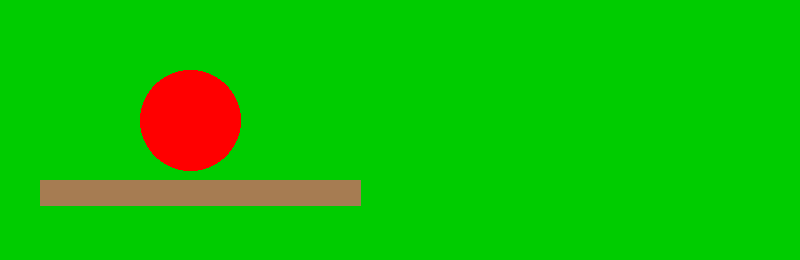

Width and height: (800, 260)


In [15]:
picture = Image.new("RGB", (800, 260), "#00CC00")
draw = ImageDraw.Draw(picture)
draw.rectangle((40, 180, 360, 205), fill="#A67C52")  # A table
draw.ellipse((140, 70, 240, 170), fill="red")         # A ball
picture.save(ASSETS / "ball.png")
display(picture)
print("Width and height:", picture.size)


### Practice 2 — Make a visual contrast
Change the ball color to blue. Move it to the left by changing its coordinates. Then match the sentence to the picture. Keep all four coordinates inside the image.


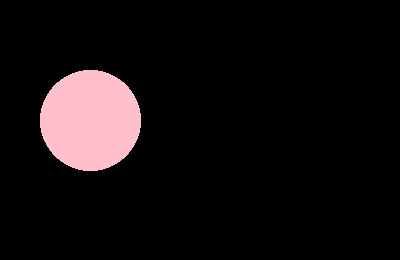

The blue ball is on the left.


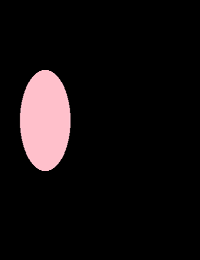

In [20]:
my_picture = Image.new("RGB", (400, 260), "black")
pen = ImageDraw.Draw(my_picture)
pen.ellipse((40, 70, 140, 170), fill="pink")  # CHANGE ME
caption = "The blue ball is on the left."  # CHANGE ME
display(my_picture)
print(caption)

small_picture = my_picture.resize((200, 260))
small_picture.save(ASSETS / "small_ball_picture.png")
display(small_picture)


### Optional — Use your own image in Colab
Run this cell only if you want to upload an image. Choose a small PNG or JPG file. Use a picture you made or have permission to use.

[bunny sample](https://github.com/MK316/Digital-Literacy-Class/raw/main/images/bunny.png)


Saving bunny.png to bunny.png


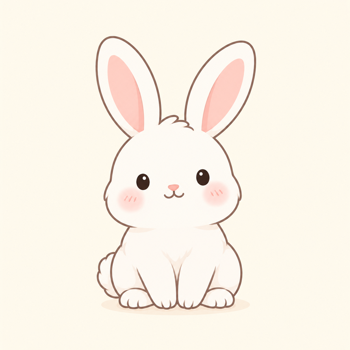

In [ ]:
from google.colab import files
uploaded = files.upload()
if uploaded:
    image_name = next(iter(uploaded))
    try:
        with Image.open(image_name) as original:
            user_picture = original.convert("RGB")
        user_picture.thumbnail((500, 350))
        display(user_picture)
    except Exception as error:
        print("Please choose a PNG or JPG image.", type(error).__name__)


In [21]:
#@markdown 참고: 이미지 데이터
import numpy as np
import matplotlib.pyplot as plt

# 1. 그림을 숫자 배열로 변환 (PIL 이미지, 텐서 등 어떤 형태든)
data = np.array(user_picture)

# 2. 기본 정보: 크기와 자료형
print("자료형(type):", type(user_picture))
print("배열 모양(shape):", data.shape)   # (세로, 가로, 채널) 예: (256, 256, 3)
print("값의 종류(dtype):", data.dtype)   # 보통 uint8 → 0~255
print("가장 작은 값:", data.min(), "/ 가장 큰 값:", data.max())

# 3. 픽셀 하나는 어떻게 생겼을까? (왼쪽 위 첫 픽셀)
print("\n왼쪽 위 픽셀 값:", data[0, 0])  # 예: [255 240 245] → 빨강, 초록, 파랑

# 4. 일부 영역(가운데 5x5)의 실제 숫자 보기
h, w = data.shape[:2]
cy, cx = h // 2, w // 2
print("\n가운데 5x5 영역의 숫자 (빨강 채널):")
print(data[cy-2:cy+3, cx-2:cx+3, 0] if data.ndim == 3 else data[cy-2:cy+3, cx-2:cx+3])

# 5. 그림 vs 확대한 픽셀 + 숫자를 나란히 보기
patch = data[cy-5:cy+5, cx-5:cx+5]
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(data)
axes[0].add_patch(plt.Rectangle((cx-5, cy-5), 10, 10, edgecolor='red', fill=False, lw=2))
axes[0].set_title("원본 그림 (빨간 네모 부분을 확대)")

axes[1].imshow(patch, interpolation='nearest')
gray = patch.mean(axis=2) if patch.ndim == 3 else patch
for i in range(patch.shape[0]):
    for j in range(patch.shape[1]):
        val = patch[i, j, 0] if patch.ndim == 3 else patch[i, j]
        axes[1].text(j, i, int(val), ha='center', va='center', fontsize=8,
                     color='white' if gray[i, j] < 128 else 'black')
axes[1].set_title("확대: 각 칸이 픽셀 하나, 숫자는 빨강 값")
plt.show()

# 6. 색 채널 분리해서 보기 (컬러 이미지인 경우)
if data.ndim == 3:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for k, (name, cmap) in enumerate(zip(["빨강(R)", "초록(G)", "파랑(B)"], ["Reds", "Greens", "Blues"])):
        axes[k].imshow(data[:, :, k], cmap=cmap)
        axes[k].set_title(f"{name} 채널")
    plt.show()


NameError: name 'user_picture' is not defined

## App 1 — Picture Vocabulary Quiz
**Modes:** image + written language. **Goal:** connect a visual clue with an English word.

Run the cell, select a word, and click **Check**. Try both a correct and an incorrect answer. The buttons run a small function: a named group of instructions.


In [22]:
app1_answer = "bunny"
app1_choices = widgets.Dropdown(
    options=["book", "bunny", "sun"], description="Word:"
)
app1_button = widgets.Button(description="Check", button_style="info")
app1_feedback = widgets.Output()

def check_picture_answer(button):
    with app1_feedback:
        app1_feedback.clear_output(wait=True)
        if app1_choices.value == app1_answer:
            print("Correct! It is a bunny.")
        else:
            print("Try again. Look at the long ears.")

app1_button.on_click(check_picture_answer)
display(user_picture)
display(widgets.VBox([app1_choices, app1_button, app1_feedback]))

NameError: name 'user_picture' is not defined

## 3. Audio: create, play, and inspect a sound
Digital audio stores samples of a sound wave. The **sample rate** tells us how many samples are stored per second. This example creates a tone, not speech.

Press the play button. Use a comfortable volume.


In [23]:
sample_rate = 16000
seconds = 3.0
frequency = 440  # CHANGE ME: try 660
sample_times = np.linspace(0, seconds, int(sample_rate * seconds), endpoint=False)
tone = 0.2 * np.sin(2 * np.pi * frequency * sample_times)
display(Audio(tone, rate=sample_rate, normalize=False))

with wave.open(str(ASSETS / "tone.wav"), "wb") as wav_file:
    wav_file.setnchannels(1)
    wav_file.setsampwidth(2)  # 16-bit samples
    wav_file.setframerate(sample_rate)
    wav_file.writeframes((tone * 32767).astype("<i2").tobytes())
print("Saved tone.wav. Number of samples:", len(tone))


Saved tone.wav. Number of samples: 16000


### Practice 3 — Compare sounds
Change `frequency` to hear a different pitch. Change `seconds` for a longer sound. Run the previous cell after each change. How is pitch different from duration?

### Turn text into speech (TTS)
This optional online service creates English speech. The text is sent to a speech service, so use the example sentence or other non-sensitive practice text. If the service is unavailable, the notebook continues and App 2 can use an uploaded recording.


In [25]:
from gtts import gTTS

listening_sentence = "I have to study hard today."
speech_path = ASSETS / "listening.mp3"
speech_ready = False
try:
    gTTS(text=listening_sentence, lang="en", slow=True, timeout=15).save(str(speech_path))
    speech_ready = True
    display(Audio(filename=str(speech_path)))
except Exception as error:
    print("Online speech is unavailable:", type(error).__name__)
    print("Use the optional recording upload below, or ask a partner to read the sentence.")


In [26]:
from gtts import gTTS

listening_sentence = input("Write your sentences.")
speech_path = ASSETS / "listening.mp3"
speech_ready = False
try:
    gTTS(text=listening_sentence, lang="en", slow=True, timeout=15).save(str(speech_path))
    speech_ready = True
    display(Audio(filename=str(speech_path)))
except Exception as error:
    print("Online speech is unavailable:", type(error).__name__)
    print("Use the optional recording upload below, or ask a partner to read the sentence.")

Write your sentences.I study hard


In [27]:
# Korean audio

korean_sentence = "이번 주말에 열심히 공부해야지!"
korean_path = ASSETS / "listening_korean.mp3"

try:
    gTTS(text=korean_sentence, lang="ko", slow=True, timeout=15).save(str(korean_path))
    print(korean_sentence)
    display(Audio(filename=str(korean_path)))
except Exception as error:
    print("Korean speech is unavailable:", type(error).__name__)

이번 주말에 열심히 공부해야지!


In [29]:
# English - Translation in Korean

from gtts import gTTS
from IPython.display import display, Audio
from pathlib import Path
import ipywidgets as widgets

ASSETS = Path("multimodality_assets")
ASSETS.mkdir(exist_ok=True)

english_sentences = [
    "The blue ball is on the table.",
    "The classroom is quiet.",
    "The bunny has long ears."
]

korean_sentences = [
    "파란 공이 탁자 위에 있어요.",
    "교실이 조용해요.",
    "토끼는 귀가 길어요."
]

sentence_choice = widgets.Dropdown(
    options=[(text, i) for i, text in enumerate(english_sentences)],
    description="Sentence:",
    layout=widgets.Layout(width="95%")
)

english_button = widgets.Button(description="English")
korean_button = widgets.Button(
    description="Translation in Korean",
    layout=widgets.Layout(width="200px")
)
audio_output = widgets.Output()

def play_audio(language):
    i = sentence_choice.value
    text = english_sentences[i] if language == "en" else korean_sentences[i]
    audio_path = ASSETS / f"sentence_{i}_{language}.mp3"

    with audio_output:
        audio_output.clear_output(wait=True)
        print(text)
        try:
            # Generate once, then reuse the saved audio.
            if not audio_path.exists():
                gTTS(text=text, lang=language, slow=True, timeout=15).save(
                    str(audio_path)
                )
            display(Audio(filename=str(audio_path), autoplay=True))
        except Exception as error:
            audio_path.unlink(missing_ok=True)
            print("Speech is unavailable:", type(error).__name__)

english_button.on_click(lambda button: play_audio("en"))
korean_button.on_click(lambda button: play_audio("ko"))

display(widgets.VBox([
    sentence_choice,
    widgets.HBox([english_button, korean_button]),
    audio_output
]))

### Optional fallback — Upload a recording
Record “The blue ball is on the table.” with a phone or another recorder, then upload a small WAV or MP3 file. If you change the sentence, change `listening_sentence` below too. Colab does not record your microphone in this cell.


In [ ]:
from google.colab import files
recordings = files.upload()
if recordings:
    speech_path = Path(next(iter(recordings)))
    listening_sentence = "The blue ball is on the table."  # Match your recording
    try:
        display(Audio(filename=str(speech_path)))
        speech_ready = True
    except Exception as error:
        speech_ready = False
        print("Please upload a playable WAV or MP3 file.", type(error).__name__)


## App 2 — Listen and Type
**Modes:** spoken language + written response. **Goal:** identify words in a short sentence.

Click **Listen**, type the sentence, and click **Check**. Capitalization, basic punctuation, and extra spaces are ignored. This is an exact sentence check after simple cleaning; it is not a pronunciation assessment.

The model sentence is visible in the earlier code. For a real listening task, work with a partner who chooses the sentence without showing you the code.


In [ ]:
#@markdown Listen and Type activity

def clean_answer(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9'\s]", "", text)
    return " ".join(text.split())

app2_input = widgets.Text(placeholder="Type what you hear", description="Answer:",
                          layout=widgets.Layout(width="95%"))
app2_listen = widgets.Button(description="Listen")
app2_check = widgets.Button(description="Check", button_style="info")
app2_reveal = widgets.Button(description="Show answer")
app2_audio = widgets.Output()
app2_feedback = widgets.Output()

def play_sentence(button):
    with app2_audio:
        app2_audio.clear_output(wait=True)
        if speech_ready:
            display(Audio(filename=str(speech_path)))
        else:
            print("Ask a partner to read the model sentence, or upload a recording above.")

def check_listening(button):
    with app2_feedback:
        app2_feedback.clear_output(wait=True)
        if not app2_input.value.strip():
            print("Type your answer first.")
        elif clean_answer(app2_input.value) == clean_answer(listening_sentence):
            print("Correct! You identified the sentence.")
        else:
            print("Listen again. Check the color and the location.")

def reveal_sentence(button):
    with app2_feedback:
        app2_feedback.clear_output(wait=True)
        print("Model sentence:", listening_sentence)

app2_listen.on_click(play_sentence)
app2_check.on_click(check_listening)
app2_reveal.on_click(reveal_sentence)
display(widgets.VBox([app2_listen, app2_audio, app2_input,
                      widgets.HBox([app2_check, app2_reveal]), app2_feedback]))


### Modify App 2
Change the model sentence to a short classroom instruction. Generate the speech again, then rerun the app cell. Update the hint in the checking function to fit your sentence.

**Discuss:** When should learners see the written sentence: before listening, after one attempt, or after several attempts? Explain your choice.


## 4. Video: combine images over time
A video is a sequence of frames. **FPS** means frames per second. We will create a silent three-second clip of a ball moving from left to right. No external video download is needed.

The loop below draws a new frame each time. The changing `x` coordinate makes movement visible. The clip is silent: video files do not always contain audio.


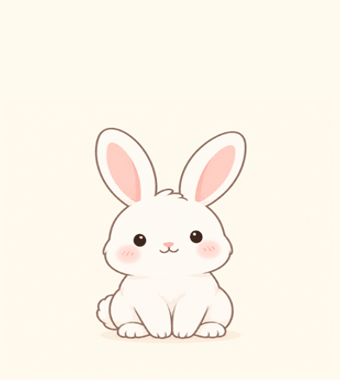

In [ ]:
#@markdown Moving image
import numpy as np
from PIL import Image
from IPython.display import Image as ShowImage, display

# 1. user_picture를 PIL 이미지로 변환
if isinstance(user_picture, Image.Image):
    bunny = user_picture.convert("RGBA")
else:
    arr = np.array(user_picture)
    if arr.dtype != np.uint8:            # 0~1 사이 실수 배열이면 0~255로 변환
        arr = (arr * 255).clip(0, 255).astype(np.uint8)
    bunny = Image.fromarray(arr).convert("RGBA")

# 크기가 너무 크면 줄이기 (GIF 용량 절약)
bunny.thumbnail((300, 300))
w, h = bunny.size

# 배경색: 그림 왼쪽 위 픽셀 색을 배경으로 사용
bg_color = bunny.getpixel((0, 0))[:3]

# 2. 프레임 만들기
frames = []
n_frames = 20
jump_height = h // 5          # 얼마나 높이 뛸지
canvas_h = h + jump_height    # 뛰어오를 공간 확보

for i in range(n_frames):
    t = i / n_frames * 2 * np.pi
    hop = abs(np.sin(t))                     # 0 → 1 → 0 : 한 번 뛰기
    angle = 8 * np.sin(t)                    # 좌우로 살짝 기울기

    # 착지할 때 살짝 납작해지는 효과
    squash = 1 - 0.1 * (1 - hop) ** 4
    frame_bunny = bunny.resize((int(w * (2 - squash)), int(h * squash)))
    frame_bunny = frame_bunny.rotate(angle, expand=True, resample=Image.BICUBIC)

    canvas = Image.new("RGBA", (w + 40, canvas_h + 20), bg_color + (255,))
    x = (canvas.width - frame_bunny.width) // 2
    y = canvas.height - frame_bunny.height - int(hop * jump_height) - 10
    canvas.paste(frame_bunny, (x, y), frame_bunny)   # 투명 부분 유지하며 붙이기
    frames.append(canvas.convert("RGB"))

# 3. GIF로 저장
frames[0].save(
    "bunny_hop.gif",
    save_all=True,
    append_images=frames[1:],
    duration=60,   # 한 프레임당 시간(ms). 작을수록 빨라짐
    loop=0,        # 0 = 무한 반복
)

# 4. 코랩에서 보여주기
display(ShowImage(filename="bunny_hop.gif"))

## App 3 — Watch and Choose
**Modes:** movement + written language, with an optional written support sentence. **Goal:** understand a motion description.

Watch the original left-to-right video, choose the sentence, and click **Check**. Use **Show support sentence** after your first attempt and compare the experience.



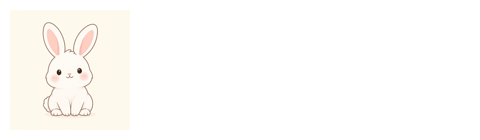

  데이터 모양(shape): (20, 140, 480, 3)



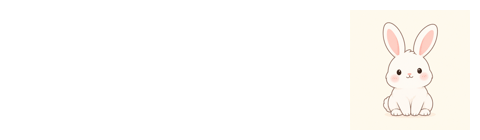

  데이터 모양(shape): (20, 140, 480, 3)



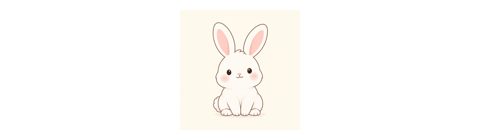

  데이터 모양(shape): (20, 140, 480, 3)


In [ ]:
#@markdown Moving image and text
import numpy as np
from PIL import Image
from IPython.display import Image as ShowImage, display, HTML
import base64

# 1. 문장 목록 (ball → bunny)
sentences = ["The bunny moves to the right.",
             "The bunny moves to the left.",
             "The bunny does not move."]

# 2. user_picture를 PIL 이미지로 변환
if isinstance(user_picture, Image.Image):
    bunny = user_picture.convert("RGBA")
else:
    arr = np.array(user_picture)
    if arr.dtype != np.uint8:
        arr = (arr * 255).clip(0, 255).astype(np.uint8)
    bunny = Image.fromarray(arr).convert("RGBA")

bunny.thumbnail((120, 120))          # 옆으로 움직일 공간을 위해 작게
w, h = bunny.size
bg_color = (255, 255, 255)           # 배경색 (흰색)
canvas_w, canvas_h = w * 4, h + 20   # 가로로 넓은 무대

# 3. 방향(direction)에 따라 프레임 만드는 함수
#    direction: +1 = 오른쪽, -1 = 왼쪽, 0 = 정지
def make_frames(direction, n_frames=20):
    frames = []
    start_x = 10 if direction >= 0 else canvas_w - w - 10
    if direction == 0:
        start_x = (canvas_w - w) // 2
    step = (canvas_w - w - 20) / (n_frames - 1)

    for i in range(n_frames):
        x = int(start_x + direction * step * i)
        canvas = Image.new("RGBA", (canvas_w, canvas_h), bg_color + (255,))
        canvas.paste(bunny, (x, 10), bunny)
        frames.append(canvas.convert("RGB"))
    return frames

# 4. 문장 ↔ 방향 연결해서 GIF 만들기
directions = [+1, -1, 0]
pairs = []   # (문장, gif 파일명, 프레임 배열)

for idx, (sentence, d) in enumerate(zip(sentences, directions)):
    frames = make_frames(d)
    filename = f"bunny_{idx}.gif"
    frames[0].save(filename, save_all=True, append_images=frames[1:],
                   duration=80, loop=0)
    video = np.stack([np.array(f) for f in frames])   # (프레임, 세로, 가로, 3)
    pairs.append((sentence, filename, video))

# 5. 문장과 GIF를 나란히 보여주기
for sentence, filename, video in pairs:
    with open(filename, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    display(HTML(f"""
        <div style="display:flex; align-items:center; gap:20px; margin:10px 0;">
            <img src="data:image/gif;base64,{b64}" style="border:1px solid #ccc;">
            <span style="font-size:18px;">{sentence}</span>
        </div>"""))
    print("  데이터 모양(shape):", video.shape)

## 5. Pair challenge — Design a small multimodal lesson
Choose **one** of the three apps and adapt it for a specific learner group.

1. Choose a target: vocabulary, listening, or movement expressions.
2. Change at least two things: content, media, choices, feedback, or support.
3. Test a correct answer, an incorrect answer, and an empty answer where applicable.
4. Ask another pair to use your app.
5. Explain the learning purpose of each mode.

**Beginner option:** Adapt an existing app. You do not need to build a new interface.
**Extension:** Add the speech from Section 3 to the picture quiz. Decide whether learners should hear it before or after answering.


In [ ]:
# Complete your design note using strings. No new library is needed.


---
This is the end.